In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install deepface -q
import os
BASE = '/content/drive/MyDrive/DatingApp_ML'
print("Ready!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.3 MB/s eta 0:00:00
Ready!


Upload a face photo:


Saving IMG_20250905_165259.jpg to IMG_20250905_165259.jpg


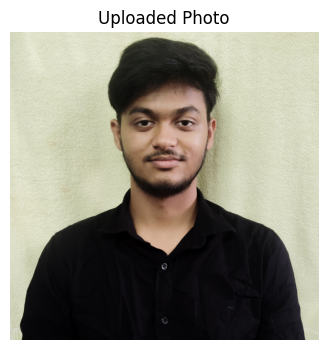

Analyzing face...


Action: emotion: 100%|██████████| 3/3 [00:02<00:00,  1.27it/s]


--- ML Analysis Results ---
Predicted Age : 25
Gender        : Man
Emotion       : neutral


In [7]:
from google.colab import files
from deepface import DeepFace
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Upload a photo (a dialog box will open)
print("Upload a face photo:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Show the image
img = mpimg.imread(img_path)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Photo")
plt.show()

# Run age prediction using DeepFace (uses VGGFace model internally)
print("Analyzing face...")
result = DeepFace.analyze(
    img_path,
    actions=['age', 'gender', 'emotion'],
    enforce_detection=False
)
predicted_age  = result[0]['age']
gender         = result[0]['dominant_gender']
emotion        = result[0]['dominant_emotion']

print(f"\n--- ML Analysis Results ---")
print(f"Predicted Age : {predicted_age}")
print(f"Gender        : {gender}")
print(f"Emotion       : {emotion}")

In [8]:
def verify_age(predicted_age, profile_age, threshold=5):
    """
    Compare predicted age from face vs age user typed in profile.
    Returns a verification result dict.
    """
    difference = abs(predicted_age - profile_age)
    is_verified = difference <= threshold

    result = {
        "predicted_age"  : predicted_age,
        "profile_age"    : profile_age,
        "difference"     : difference,
        "is_verified"    : is_verified,
        "message"        : "Age verified" if is_verified else f"Age mismatch! Difference: {difference} years"
    }
    return result

# Test it — pretend user said they are 25
profile_age = int(input("Enter profile age to test: "))
verification = verify_age(predicted_age, profile_age)

print("\n--- Verification Result ---")
for key, val in verification.items():
    print(f"{key}: {val}")

# Save result to Drive
import json
result_path = f'{BASE}/results/age_verification_test.json'
with open(result_path, 'w') as f:
    json.dump(verification, f, indent=2)
print(f"\nResult saved to: {result_path}")


Enter profile age to test: 21

--- Verification Result ---
predicted_age: 25
profile_age: 21
difference: 4
is_verified: True
message: Age verified

Result saved to: /content/drive/MyDrive/DatingApp_ML/results/age_verification_test.json


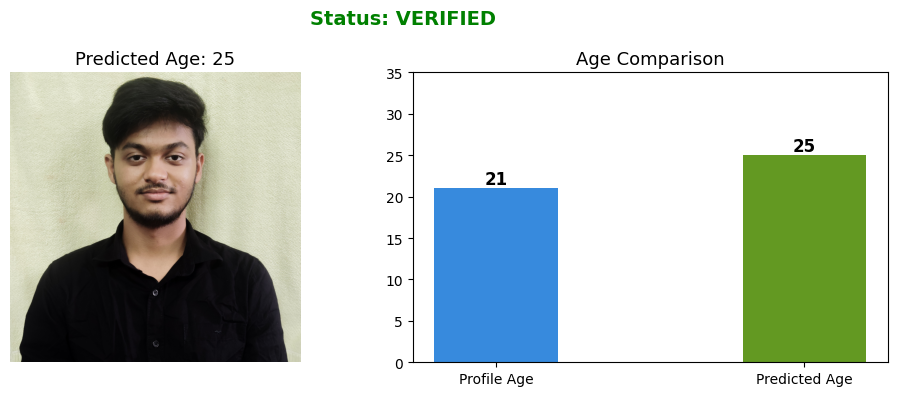

Chart saved to Drive!


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: show face
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title(f"Predicted Age: {predicted_age}", fontsize=13)
axes[0].axis('off')

# Right: age comparison bar chart
ages = ['Profile Age', 'Predicted Age']
values = [profile_age, predicted_age]
colors = ['#378ADD', '#E24B4A' if not verification['is_verified'] else '#639922']
bars = axes[1].bar(ages, values, color=colors, width=0.4)
axes[1].set_ylim(0, max(values) + 10)
axes[1].set_title("Age Comparison", fontsize=13)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=12, fontweight='bold')

status = "VERIFIED" if verification['is_verified'] else "FLAGGED"
fig.suptitle(f"Status: {status}", fontsize=14, fontweight='bold',
             color='green' if verification['is_verified'] else 'red')
plt.tight_layout()
plt.savefig(f'{BASE}/results/age_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")
